In [1]:
# Step 1: environment check + package location + core imports

import os
import sys
import site
import platform
import importlib
import importlib.util
from pathlib import Path

print("=" * 80)
print("PYTHON / CONDA / JUPYTER ENVIRONMENT")
print("=" * 80)
print(f"Python executable : {sys.executable}")
print(f"Python version    : {sys.version.splitlines()[0]}")
print(f"Platform          : {platform.platform()}")
print(f"Working directory : {os.getcwd()}")
print(f"CONDA_PREFIX      : {os.environ.get('CONDA_PREFIX', 'Not set')}")
print(f"CONDA_DEFAULT_ENV : {os.environ.get('CONDA_DEFAULT_ENV', 'Not set')}")
print()

print("=" * 80)
print("SITE-PACKAGES PATHS")
print("=" * 80)
for p in site.getsitepackages():
    print(p)
print()

# Optional: show a few sys.path entries for debugging import issues
print("=" * 80)
print("FIRST FEW sys.path ENTRIES")
print("=" * 80)
for p in sys.path[:10]:
    print(p)
print()

def locate_module(module_name: str):
    """Locate a Python module/package on disk without importing it yet."""
    spec = importlib.util.find_spec(module_name)
    if spec is None:
        return None, None
    origin = spec.origin
    search_locations = list(spec.submodule_search_locations) if spec.submodule_search_locations else None
    return origin, search_locations

modules_to_check = [
    "habitat_sim",   # Habitat-Sim
    "habitat",       # Habitat-Lab usually imports as habitat
    "numpy",
    "matplotlib",
    "networkx",
    "torch",
    "cv2",           # OpenCV
]

print("=" * 80)
print("MODULE LOCATIONS")
print("=" * 80)
for m in modules_to_check:
    origin, search_locations = locate_module(m)
    print(f"\nModule: {m}")
    if origin is None and search_locations is None:
        print("  Status : NOT FOUND")
    else:
        print(f"  Origin : {origin}")
        if search_locations:
            print("  Package directories:")
            for loc in search_locations:
                print(f"    - {loc}")
print()

print("=" * 80)
print("IMPORT TESTS")
print("=" * 80)

# Core imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Optional imports with graceful failure
optional_results = {}

try:
    import torch
    optional_results["torch"] = f"OK | version={torch.__version__}"
except Exception as e:
    optional_results["torch"] = f"FAILED | {type(e).__name__}: {e}"

try:
    import cv2
    optional_results["cv2"] = f"OK | version={cv2.__version__}"
except Exception as e:
    optional_results["cv2"] = f"FAILED | {type(e).__name__}: {e}"

try:
    import habitat_sim
    optional_results["habitat_sim"] = f"OK | version={getattr(habitat_sim, '__version__', 'unknown')}"
except Exception as e:
    optional_results["habitat_sim"] = f"FAILED | {type(e).__name__}: {e}"

try:
    import habitat
    optional_results["habitat"] = f"OK | version={getattr(habitat, '__version__', 'unknown')}"
except Exception as e:
    optional_results["habitat"] = f"FAILED | {type(e).__name__}: {e}"

for k, v in optional_results.items():
    print(f"{k:12s}: {v}")

print()
print("=" * 80)
print("SANITY CHECK COMPLETE")
print("=" * 80)

# Convenience aliases / settings for later notebook cells
np.set_printoptions(precision=4, suppress=True)

print("\nReady for Step 2 if habitat_sim and habitat both imported successfully.")

PYTHON / CONDA / JUPYTER ENVIRONMENT
Python executable : /home/rithvik/miniconda3/envs/iros-train/bin/python
Python version    : 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
Platform          : Linux-6.8.0-106-generic-x86_64-with-glibc2.35
Working directory : /home/rithvik/IROS_proj/llm_test/external
CONDA_PREFIX      : /home/rithvik/miniconda3/envs/iros-train
CONDA_DEFAULT_ENV : iros-train

SITE-PACKAGES PATHS
/home/rithvik/miniconda3/envs/iros-train/lib/python3.10/site-packages

FIRST FEW sys.path ENTRIES
/home/rithvik/miniconda3/envs/iros-train/lib/python310.zip
/home/rithvik/miniconda3/envs/iros-train/lib/python3.10
/home/rithvik/miniconda3/envs/iros-train/lib/python3.10/lib-dynload

/home/rithvik/.local/lib/python3.10/site-packages
/home/rithvik/miniconda3/envs/iros-train/lib/python3.10/site-packages
__editable__.vila-1.0.0.finder.__path_hook__

MODULE LOCATIONS

Module: habitat_sim
  Origin : /home/rithvik/miniconda3/envs/iros-train/lib/python3.10/site-packages/habitat_sim/

In [8]:
# Block 1: search and select a Habitat renderable scene (.glb preferred)

from pathlib import Path

def find_glb_scenes(search_roots):
    glb_files = []
    for root in search_roots:
        root = Path(root).expanduser()
        if not root.exists():
            continue
        for p in root.rglob("*.glb"):
            if p.is_file():
                glb_files.append(p)
    return sorted(glb_files)

search_roots = [
    "/home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d",
    "/home/rithvik/IROS_proj",
    ".",
]

glb_files = find_glb_scenes(search_roots)

print("=" * 80)
print("FOUND .GLB SCENES")
print("=" * 80)
for i, p in enumerate(glb_files[:50]):
    print(f"[{i:02d}] {p}")

if len(glb_files) == 0:
    raise FileNotFoundError("No .glb scenes found in the search roots.")

# Prefer a normal mp3d .glb, not semantic assets
preferred = None
for p in glb_files:
    s = str(p).lower()
    if "mp3d" in s and "_semantic" not in s:
        preferred = p
        break

if preferred is None:
    preferred = glb_files[0]

SCENE_PATH = str(preferred)

print("\n" + "=" * 80)
print("SELECTED SCENE")
print("=" * 80)
print(SCENE_PATH)

FOUND .GLB SCENES
[00] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[01] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[02] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/1LXtFkjw3qL/1LXtFkjw3qL.glb
[03] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/1LXtFkjw3qL/1LXtFkjw3qL.glb
[04] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/1pXnuDYAj8r/1pXnuDYAj8r.glb
[05] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/1pXnuDYAj8r/1pXnuDYAj8r.glb
[06] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/29hnd4uzFmX/29hnd4uzFmX.glb
[07] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/29hnd4uzFmX/29hnd4uzFmX.glb
[08] /home/rithvik/IROS_proj/NaVILA_iros/evaluation/data/scene_datasets/mp3d/2azQ1b91cZZ/2azQ1b91cZZ.glb
[09] /home/rithvik/IROS_proj/NaVILA_i

Renderer: NVIDIA RTX A6000/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_ES2_compatibility
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_invalidate_subdata
    GL_ARB_multi_bind
    GL_ARB_robustness
    GL_ARB_separate_shader_objects
    GL_ARB_texture_filter_anisotropic
    GL_ARB_texture_storage
    GL_ARB_texture_storage_multisample
    GL_ARB_vertex_array_object
    GL_KHR_debug
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


I0323 17:13:08.315337 932789 ManagedContainerBase.cpp:19] ManagedContainerBase::convertFilenameToJSON : Filename : default changed to proposed JSON configuration filename : default.scene_dataset_config.json
I0323 17:13:08.315363 932789 AttributesManagerBase.h:283] AttributesManager<T>::createFromJsonOrDefaultInternal  (Dataset) : Proposing JSON name : default.scene_dataset_config.json from original name : default | This file  does not exist.
I0323 17:13:08.315423 932789 AssetAttributesManager.cpp:117] Asset attributes (capsule3DSolid : capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
I0323 17:13:08.315447 932789 AssetAttributesManager.cpp:117] Asset attributes (capsule3DWireframe : capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
I0323 17:13:08.315467 932789 AssetAttributesManager.cpp:117] Asset attributes (coneSolid : coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoor

Simulator initialized successfully.
NavMesh loaded: True
Agent start position: [0.393  0.0724 0.1452]
Observation keys: ['rgb']
RGB shape: (480, 640, 4)
RGB dtype: uint8


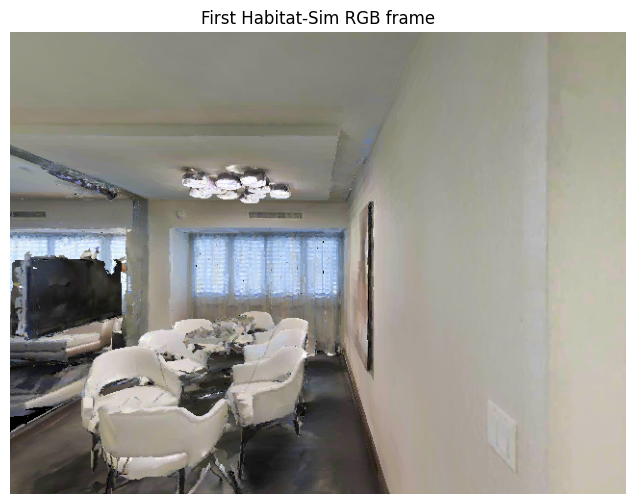

In [9]:
# Block 2: initialize Habitat-Sim and render one RGB frame
# Compatible with your habitat_sim 0.1.7 build

import numpy as np
import matplotlib.pyplot as plt
import habitat_sim


def make_simple_sim_cfg(scene_path: str, width: int = 640, height: int = 480, sensor_height: float = 1.5):
    # Simulator configuration
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = scene_path
    sim_cfg.enable_physics = False

    # Agent configuration
    try:
        agent_cfg = habitat_sim.AgentConfiguration()
    except AttributeError:
        agent_cfg = habitat_sim.agent.AgentConfiguration()

    # Sensor configuration
    rgb_sensor = habitat_sim.SensorSpec()
    rgb_sensor.uuid = "rgb"
    rgb_sensor.sensor_type = habitat_sim.SensorType.COLOR
    rgb_sensor.resolution = [height, width]
    rgb_sensor.position = [0.0, sensor_height, 0.0]

    # hfov may or may not exist depending on build
    if hasattr(rgb_sensor, "hfov"):
        rgb_sensor.hfov = 90

    agent_cfg.sensor_specifications = [rgb_sensor]

    return habitat_sim.Configuration(sim_cfg, [agent_cfg])


# Clean up previous simulator if this cell is rerun
try:
    sim.close()
    print("Closed previous simulator.")
except Exception:
    pass

cfg = make_simple_sim_cfg(SCENE_PATH)
sim = habitat_sim.Simulator(cfg)
print("Simulator initialized successfully.")

# Initialize agent
agent = sim.initialize_agent(0)

# Create agent state
state = habitat_sim.AgentState()

# Place the agent
pathfinder = sim.pathfinder
print("NavMesh loaded:", pathfinder.is_loaded)

if pathfinder.is_loaded:
    start_pos = pathfinder.get_random_navigable_point()
else:
    start_pos = np.array([0.0, 0.0, 0.0], dtype=np.float32)

state.position = start_pos
agent.set_state(state)

print("Agent start position:", agent.get_state().position)

# Render one frame
obs = sim.get_sensor_observations()
print("Observation keys:", list(obs.keys()))

rgb = obs["rgb"]
print("RGB shape:", rgb.shape)
print("RGB dtype:", rgb.dtype)

# If RGBA, keep first 3 channels
rgb_vis = rgb[..., :3] if rgb.ndim == 3 and rgb.shape[-1] >= 3 else rgb

plt.figure(figsize=(8, 6))
plt.imshow(rgb_vis)
plt.title("First Habitat-Sim RGB frame")
plt.axis("off")
plt.show()

AVAILABLE ACTION SPACE
move_forward    -> ActionSpec(name='move_forward', actuation=ActuationSpec(amount=0.25, constraint=None))
turn_left       -> ActionSpec(name='turn_left', actuation=ActuationSpec(amount=10.0, constraint=None))
turn_right      -> ActionSpec(name='turn_right', actuation=ActuationSpec(amount=10.0, constraint=None))

Available action names: ['move_forward', 'turn_left', 'turn_right']

INITIAL AGENT STATE
start_position   : [0.393  0.0724 0.1452]
start_rotation   : quaternion(1, 0, 0, 0)

Chosen action sequence: ['move_forward', 'turn_left', 'turn_right']

TRANSITION LOG
step 01 | action=move_forward
  pos_before = [0.393  0.0724 0.1452]
  pos_after  = [ 0.393   0.0724 -0.1048]
  delta_pos  = [ 0.    0.   -0.25]
step 02 | action=turn_left
  pos_before = [ 0.393   0.0724 -0.1048]
  pos_after  = [ 0.393   0.0724 -0.1048]
  delta_pos  = [0. 0. 0.]
step 03 | action=turn_right
  pos_before = [ 0.393   0.0724 -0.1048]
  pos_after  = [ 0.393   0.0724 -0.1048]
  delta_pos  = [

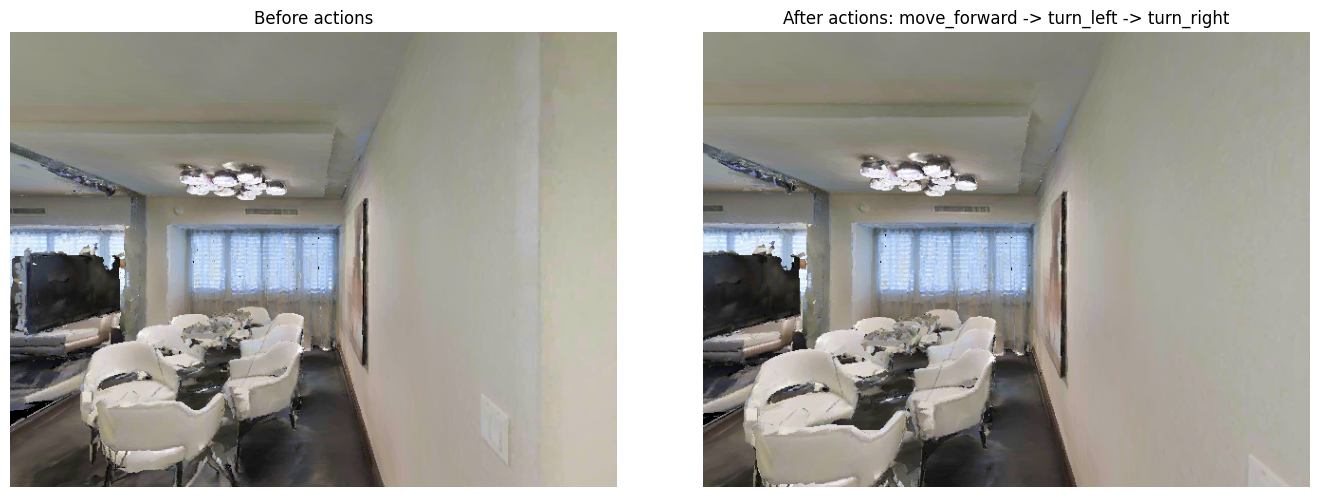

In [10]:
# Step 3: inspect agent pose, define primitive actions, take a few steps,
# and visualize before/after frames.

import numpy as np
import matplotlib.pyplot as plt
import habitat_sim


# ------------------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------------------

def quat_to_numpy(q):
    """
    Convert Habitat quaternion / Magnum quaternion into a compact printable form.
    This avoids API-specific assumptions.
    """
    try:
        # some builds expose vector + scalar
        return np.array([q.vector.x, q.vector.y, q.vector.z, q.scalar], dtype=np.float32)
    except Exception:
        try:
            # fallback if object already behaves like an iterable
            return np.array(q, dtype=np.float32)
        except Exception:
            return q


def print_agent_state(agent, prefix=""):
    st = agent.get_state()
    pos = np.array(st.position)
    rot = quat_to_numpy(st.rotation)

    print(f"{prefix}position   : {pos}")
    print(f"{prefix}rotation   : {rot}")


def get_rgb(sim):
    obs = sim.get_sensor_observations()
    rgb = obs["rgb"]
    rgb_vis = rgb[..., :3] if rgb.ndim == 3 and rgb.shape[-1] >= 3 else rgb
    return rgb_vis


def show_two_frames(img1, title1, img2, title2):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(title2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------------------
# 1) Inspect available agent actions
# ------------------------------------------------------------------------------

agent_cfg = sim.config.agents[0]

print("=" * 80)
print("AVAILABLE ACTION SPACE")
print("=" * 80)
for action_name, action_spec in agent_cfg.action_space.items():
    print(f"{action_name:15s} -> {action_spec}")

available_actions = list(agent_cfg.action_space.keys())
print("\nAvailable action names:", available_actions)


# ------------------------------------------------------------------------------
# 2) Capture initial state and frame
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("INITIAL AGENT STATE")
print("=" * 80)
print_agent_state(agent, prefix="start_")

rgb_before = get_rgb(sim)


# ------------------------------------------------------------------------------
# 3) Pick a simple action sequence robustly
# ------------------------------------------------------------------------------

# Try to use common Habitat action names if available
candidate_sequence = []

if "move_forward" in available_actions:
    candidate_sequence.append("move_forward")
elif "forward" in available_actions:
    candidate_sequence.append("forward")

if "turn_left" in available_actions:
    candidate_sequence.append("turn_left")
elif "left" in available_actions:
    candidate_sequence.append("left")

if "turn_right" in available_actions:
    candidate_sequence.append("turn_right")
elif "right" in available_actions:
    candidate_sequence.append("right")

# If none of the common names exist, just use the first 1-3 available actions
if len(candidate_sequence) == 0:
    candidate_sequence = available_actions[: min(3, len(available_actions))]

print("\nChosen action sequence:", candidate_sequence)


# ------------------------------------------------------------------------------
# 4) Step the simulator and record transitions
# ------------------------------------------------------------------------------

transition_log = []

for i, action_name in enumerate(candidate_sequence, start=1):
    st_before = agent.get_state()
    pos_before = np.array(st_before.position, dtype=np.float32)

    # perform action
    _ = sim.step(action_name)

    st_after = agent.get_state()
    pos_after = np.array(st_after.position, dtype=np.float32)

    delta = pos_after - pos_before

    transition_log.append({
        "step": i,
        "action": action_name,
        "pos_before": pos_before,
        "pos_after": pos_after,
        "delta_pos": delta,
    })

print("\n" + "=" * 80)
print("TRANSITION LOG")
print("=" * 80)
for item in transition_log:
    print(f"step {item['step']:02d} | action={item['action']}")
    print(f"  pos_before = {item['pos_before']}")
    print(f"  pos_after  = {item['pos_after']}")
    print(f"  delta_pos  = {item['delta_pos']}")


# ------------------------------------------------------------------------------
# 5) Capture final state and frame
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL AGENT STATE")
print("=" * 80)
print_agent_state(agent, prefix="end_")

rgb_after = get_rgb(sim)


# ------------------------------------------------------------------------------
# 6) Visualize before vs after
# ------------------------------------------------------------------------------

show_two_frames(
    rgb_before, "Before actions",
    rgb_after,  f"After actions: {' -> '.join(candidate_sequence)}"
)

ROLLOUT START STATE
start_position: [-1.9803  0.0724 -2.3246]
start_rotation: [1. 0. 0. 0.]

Available actions: ['move_forward', 'turn_left', 'turn_right']
Rollout length: 12
Sampling pool : ['move_forward', 'move_forward', 'move_forward', 'turn_left', 'turn_right']

TRAJECTORY SUMMARY
t=00 | action=        None | pos=[-1.9803  0.0724 -2.3246] | delta=[0. 0. 0.]
t=01 | action=move_forward | pos=[-1.9803  0.0724 -2.5746] | delta=[ 0.    0.   -0.25]
t=02 | action=move_forward | pos=[-1.9803  0.0724 -2.8246] | delta=[ 0.    0.   -0.25]
t=03 | action=move_forward | pos=[-1.9803  0.0724 -3.0746] | delta=[ 0.    0.   -0.25]
t=04 | action=   turn_left | pos=[-1.9803  0.0724 -3.0746] | delta=[0. 0. 0.]
t=05 | action=   turn_left | pos=[-1.9803  0.0724 -3.0746] | delta=[0. 0. 0.]
t=06 | action=move_forward | pos=[-2.015   0.0724 -3.308 ] | delta=[-0.0347  0.     -0.2334]
t=07 | action=  turn_right | pos=[-2.015   0.0724 -3.308 ] | delta=[0. 0. 0.]
t=08 | action=   turn_left | pos=[-2.015   0.07

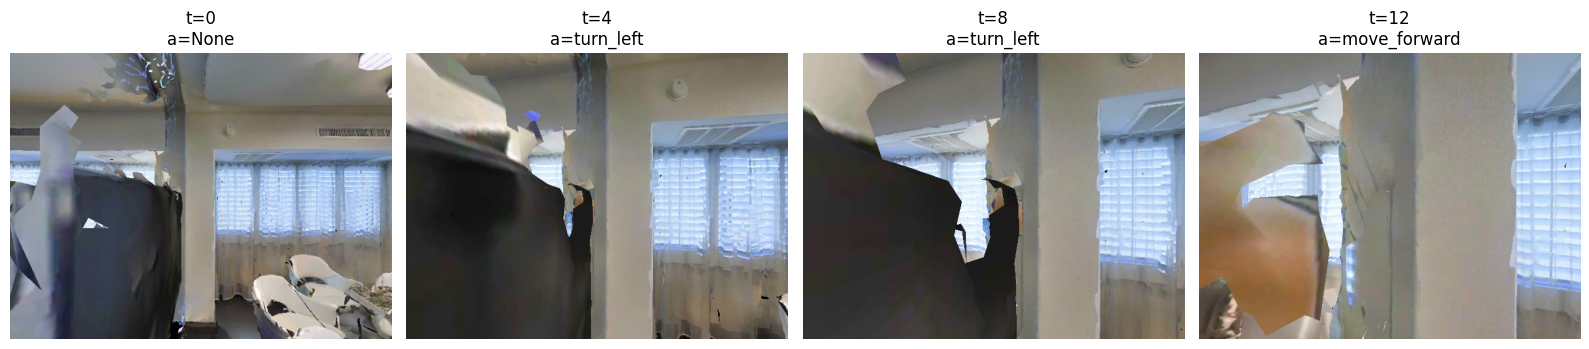

In [11]:
# Step 4: collect a short trajectory rollout and store
# {rgb_t, position_t, rotation_t, action_t, delta_position_t}

import numpy as np
import matplotlib.pyplot as plt
import random
from pprint import pprint


# ------------------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------------------

def safe_rotation_repr(q):
    """
    Return a printable/storable representation of the quaternion.
    """
    try:
        return np.array([q.w, q.x, q.y, q.z], dtype=np.float32)
    except Exception:
        try:
            return np.array([q.scalar, q.vector.x, q.vector.y, q.vector.z], dtype=np.float32)
        except Exception:
            return str(q)


def get_agent_pose(agent):
    st = agent.get_state()
    pos = np.array(st.position, dtype=np.float32)
    rot = safe_rotation_repr(st.rotation)
    return pos, rot


def get_rgb_frame(sim):
    obs = sim.get_sensor_observations()
    rgb = obs["rgb"]
    rgb = rgb[..., :3] if rgb.ndim == 3 and rgb.shape[-1] >= 3 else rgb
    return rgb


def reset_agent_to_random_navigable(sim, agent):
    """
    Reset agent to a random navigable point with identity rotation.
    """
    state = habitat_sim.AgentState()

    if sim.pathfinder.is_loaded:
        state.position = sim.pathfinder.get_random_navigable_point()
    else:
        state.position = np.array([0.0, 0.0, 0.0], dtype=np.float32)

    # Keep default identity rotation
    agent.set_state(state)
    return state


# ------------------------------------------------------------------------------
# 1) Reset agent to a clean random starting point
# ------------------------------------------------------------------------------

reset_agent_to_random_navigable(sim, agent)

start_pos, start_rot = get_agent_pose(agent)

print("=" * 80)
print("ROLLOUT START STATE")
print("=" * 80)
print("start_position:", start_pos)
print("start_rotation:", start_rot)


# ------------------------------------------------------------------------------
# 2) Define rollout parameters
# ------------------------------------------------------------------------------

available_actions = list(sim.config.agents[0].action_space.keys())
print("\nAvailable actions:", available_actions)

num_steps = 12

# Optional: bias toward forward motion so trajectory is meaningful
action_sampling_pool = []
for a in available_actions:
    if a == "move_forward":
        action_sampling_pool.extend([a, a, a])  # bias forward
    else:
        action_sampling_pool.append(a)

print("Rollout length:", num_steps)
print("Sampling pool :", action_sampling_pool)


# ------------------------------------------------------------------------------
# 3) Record trajectory
# ------------------------------------------------------------------------------

trajectory = []

# Record initial observation at t=0
pos0, rot0 = get_agent_pose(agent)
rgb0 = get_rgb_frame(sim)

trajectory.append({
    "t": 0,
    "action": None,
    "position": pos0.copy(),
    "rotation": rot0.copy() if isinstance(rot0, np.ndarray) else rot0,
    "delta_position": np.zeros(3, dtype=np.float32),
    "rgb": rgb0.copy(),
})

for t in range(1, num_steps + 1):
    action = random.choice(action_sampling_pool)

    pos_before, rot_before = get_agent_pose(agent)

    # Execute one action
    sim.step(action)

    pos_after, rot_after = get_agent_pose(agent)
    rgb_after = get_rgb_frame(sim)

    delta_pos = pos_after - pos_before

    trajectory.append({
        "t": t,
        "action": action,
        "position": pos_after.copy(),
        "rotation": rot_after.copy() if isinstance(rot_after, np.ndarray) else rot_after,
        "delta_position": delta_pos.copy(),
        "rgb": rgb_after.copy(),
    })


# ------------------------------------------------------------------------------
# 4) Print compact trajectory summary
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("TRAJECTORY SUMMARY")
print("=" * 80)

for item in trajectory:
    t = item["t"]
    action = item["action"]
    pos = item["position"]
    dpos = item["delta_position"]

    print(
        f"t={t:02d} | "
        f"action={str(action):>12s} | "
        f"pos={np.round(pos, 4)} | "
        f"delta={np.round(dpos, 4)}"
    )


# ------------------------------------------------------------------------------
# 5) Stack arrays for later ML use
# ------------------------------------------------------------------------------

positions = np.stack([x["position"] for x in trajectory], axis=0)
delta_positions = np.stack([x["delta_position"] for x in trajectory], axis=0)
rgb_frames = np.stack([x["rgb"] for x in trajectory], axis=0)

actions = [x["action"] for x in trajectory]
rotations = [x["rotation"] for x in trajectory]

print("\n" + "=" * 80)
print("STACKED ARRAY SHAPES")
print("=" * 80)
print("positions.shape      :", positions.shape)       # [T+1, 3]
print("delta_positions.shape:", delta_positions.shape) # [T+1, 3]
print("rgb_frames.shape     :", rgb_frames.shape)      # [T+1, H, W, C]
print("num_actions          :", len(actions))
print("num_rotations        :", len(rotations))


# ------------------------------------------------------------------------------
# 6) Show a few frames from the trajectory
# ------------------------------------------------------------------------------

n_show = min(4, len(trajectory))
idxs = np.linspace(0, len(trajectory) - 1, n_show).astype(int)

plt.figure(figsize=(16, 4))
for i, idx in enumerate(idxs, start=1):
    plt.subplot(1, n_show, i)
    plt.imshow(trajectory[idx]["rgb"])
    plt.title(f"t={trajectory[idx]['t']}\na={trajectory[idx]['action']}")
    plt.axis("off")
plt.tight_layout()
plt.show()

YAW / HEADING SUMMARY
t=00 | action=        None | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=01 | action=move_forward | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=02 | action=move_forward | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=03 | action=move_forward | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=04 | action=   turn_left | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=05 | action=   turn_left | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=06 | action=move_forward | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=07 | action=  turn_right | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=08 | action=   turn_left | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=09 | action=move_forward | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=10 | action=   turn_left | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=11 | action=  turn_right | yaw(rad)= 0.0000 | yaw(deg)= 0.00 | dyaw(deg)= 0.00
t=12 |

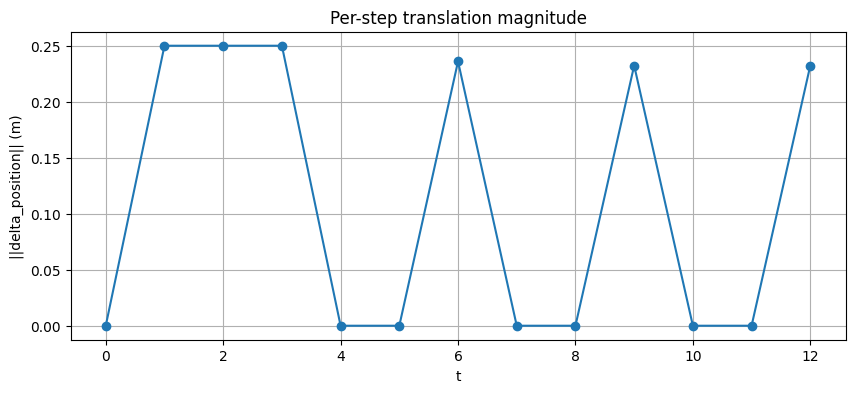

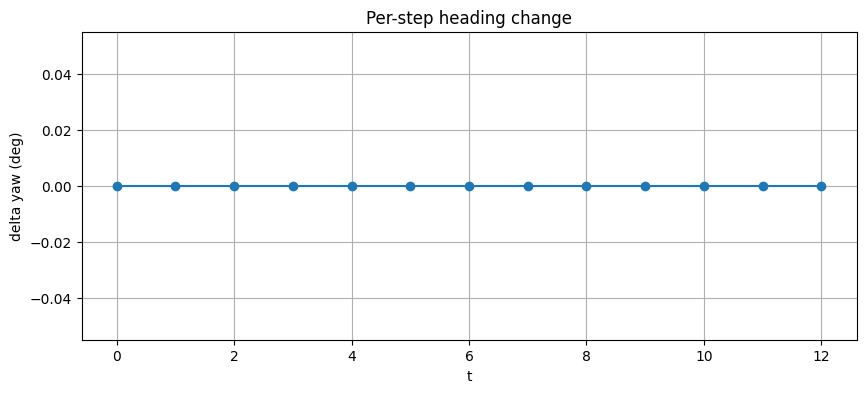


TORCH MOTION TENSOR
motion_tensor.shape: (1, 13, 5)


In [12]:
# Step 5: extract yaw / heading change and build motion features
# motion feature per step = [dx, dy, dz, sin(dyaw), cos(dyaw)]

import numpy as np
import math
import matplotlib.pyplot as plt


# ------------------------------------------------------------------------------
# Helper: robust quaternion -> yaw extraction
# ------------------------------------------------------------------------------

def quat_components(q):
    """
    Return quaternion as (w, x, y, z) from Habitat/Magnum/numpy/string-like objects.
    """
    # Case 1: numpy array already stored in [w, x, y, z]
    if isinstance(q, np.ndarray):
        q = q.astype(np.float32).reshape(-1)
        if q.shape[0] == 4:
            return float(q[0]), float(q[1]), float(q[2]), float(q[3])

    # Case 2: quaternion object with w,x,y,z
    for attrs in [("w", "x", "y", "z"), ("real", "imag", None, None)]:
        try:
            if attrs[2] is not None:
                return float(getattr(q, attrs[0])), float(getattr(q, attrs[1])), float(getattr(q, attrs[2])), float(getattr(q, attrs[3]))
        except Exception:
            pass

    # Case 3: Habitat/Magnum style: scalar + vector.{x,y,z}
    try:
        return float(q.scalar), float(q.vector.x), float(q.vector.y), float(q.vector.z)
    except Exception:
        pass

    # Case 4: string form like quaternion(1, 0, 0, 0)
    s = str(q).strip()
    if s.startswith("quaternion(") and s.endswith(")"):
        vals = s[len("quaternion("):-1].split(",")
        vals = [float(v.strip()) for v in vals]
        if len(vals) == 4:
            return vals[0], vals[1], vals[2], vals[3]

    raise ValueError(f"Could not parse quaternion: {q}")


def quat_to_yaw(q):
    """
    Convert quaternion to yaw angle (rotation around vertical axis).
    Assumes quaternion order (w, x, y, z).
    Returns yaw in radians.
    """
    w, x, y, z = quat_components(q)

    # Standard yaw extraction from quaternion
    # yaw = atan2(2(wz + xy), 1 - 2(y^2 + z^2))
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(siny_cosp, cosy_cosp)
    return yaw


def wrap_to_pi(angle):
    """
    Wrap angle to [-pi, pi].
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi


# ------------------------------------------------------------------------------
# 1) Compute yaw for every timestep in the rollout
# ------------------------------------------------------------------------------

yaws = np.array([quat_to_yaw(r) for r in rotations], dtype=np.float32)

# dyaw[t] = yaw[t] - yaw[t-1], wrapped to [-pi, pi]
dyaws = np.zeros_like(yaws)
for t in range(1, len(yaws)):
    dyaws[t] = wrap_to_pi(yaws[t] - yaws[t - 1])

print("=" * 80)
print("YAW / HEADING SUMMARY")
print("=" * 80)
for t in range(len(yaws)):
    action = actions[t]
    print(
        f"t={t:02d} | action={str(action):>12s} | "
        f"yaw(rad)={yaws[t]: .4f} | yaw(deg)={np.degrees(yaws[t]): .2f} | "
        f"dyaw(deg)={np.degrees(dyaws[t]): .2f}"
    )


# ------------------------------------------------------------------------------
# 2) Build motion feature tensor for the GRU
# ------------------------------------------------------------------------------

# We already have:
# delta_positions.shape = [T, 3]  where columns are [dx, dy, dz]
# dyaws.shape           = [T]

motion_features = np.concatenate(
    [
        delta_positions.astype(np.float32),                       # [dx, dy, dz]
        np.sin(dyaws)[:, None].astype(np.float32),               # [sin(dyaw)]
        np.cos(dyaws)[:, None].astype(np.float32),               # [cos(dyaw)]
    ],
    axis=1
)

print("\n" + "=" * 80)
print("MOTION FEATURE SHAPE")
print("=" * 80)
print("motion_features.shape:", motion_features.shape)
print("feature format       : [dx, dy, dz, sin(dyaw), cos(dyaw)]")

print("\nFirst few motion feature rows:")
print(np.round(motion_features[:8], 4))


# ------------------------------------------------------------------------------
# 3) Optional normalization for GRU input
# ------------------------------------------------------------------------------

# For your Habitat setup:
# move_forward = 0.25 m
# turn_left/right = 10 deg
#
# Normalized version can help GRU training.

forward_step_m = 0.25
turn_step_rad = np.deg2rad(10.0)

motion_features_norm = motion_features.copy()
motion_features_norm[:, 0:3] = motion_features_norm[:, 0:3] / forward_step_m

# Convert sin/cos representation to remain bounded already; no need to scale them.

print("\n" + "=" * 80)
print("NORMALIZED MOTION FEATURE PREVIEW")
print("=" * 80)
print("motion_features_norm.shape:", motion_features_norm.shape)
print(np.round(motion_features_norm[:8], 4))


# ------------------------------------------------------------------------------
# 4) Visualize translation magnitude and heading change
# ------------------------------------------------------------------------------

translation_mag = np.linalg.norm(delta_positions, axis=1)
dyaw_deg = np.degrees(dyaws)

plt.figure(figsize=(10, 4))
plt.plot(translation_mag, marker="o")
plt.xlabel("t")
plt.ylabel("||delta_position|| (m)")
plt.title("Per-step translation magnitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(dyaw_deg, marker="o")
plt.xlabel("t")
plt.ylabel("delta yaw (deg)")
plt.title("Per-step heading change")
plt.grid(True)
plt.show()


# ------------------------------------------------------------------------------
# 5) Store a GRU-ready tensor if torch is available
# ------------------------------------------------------------------------------

try:
    import torch

    # shape: [1, T, D] for batch-first GRU
    motion_tensor = torch.tensor(motion_features_norm, dtype=torch.float32).unsqueeze(0)

    print("\n" + "=" * 80)
    print("TORCH MOTION TENSOR")
    print("=" * 80)
    print("motion_tensor.shape:", tuple(motion_tensor.shape))  # [1, T, 5]

except Exception as e:
    print("\nTorch tensor creation skipped:", e)

In [1]:
# Step A: inspect the large JSON structure without dumping the whole file

import json
from pathlib import Path
from collections import Counter
from pprint import pprint

JSON_PATH = Path("/home/rithvik/IROS_proj/NaVILA-Dataset/R2R/pose_deltas/train_r2r_img_motion_8colsq_segmented.json")

print("=" * 100)
print("FILE CHECK")
print("=" * 100)
print("Exists:", JSON_PATH.exists())
print("Path  :", JSON_PATH)

if not JSON_PATH.exists():
    raise FileNotFoundError(JSON_PATH)

print("Size (GB):", round(JSON_PATH.stat().st_size / (1024**3), 4))


print("\n" + "=" * 100)
print("LOADING JSON (this may take some time if the file is very large)")
print("=" * 100)

with open(JSON_PATH, "r") as f:
    data = json.load(f)

print("Loaded successfully.")


print("\n" + "=" * 100)
print("TOP-LEVEL STRUCTURE")
print("=" * 100)
print("Top-level type:", type(data))

if isinstance(data, dict):
    print("Top-level keys:")
    pprint(list(data.keys())[:50])

    # If dict, try to identify a likely record container
    for k, v in data.items():
        if isinstance(v, list):
            print(f"\nCandidate list field: {k} | length={len(v)}")
        elif isinstance(v, dict):
            print(f"\nNested dict field: {k} | num_keys={len(v)}")

elif isinstance(data, list):
    print("Number of top-level records:", len(data))

else:
    print("Unexpected top-level structure. Stopping inspection.")


print("\n" + "=" * 100)
print("LOCATE SAMPLE RECORD")
print("=" * 100)

# Find a representative sample record
sample = None

if isinstance(data, list):
    if len(data) == 0:
        raise ValueError("Top-level list is empty.")
    sample = data[0]

elif isinstance(data, dict):
    # choose the first list-valued field with non-empty entries
    candidate_key = None
    for k, v in data.items():
        if isinstance(v, list) and len(v) > 0:
            candidate_key = k
            sample = v[0]
            print("Using record from field:", candidate_key)
            break

    if sample is None:
        raise ValueError("Could not find a non-empty list of records inside the dict.")

print("Sample record type:", type(sample))


print("\n" + "=" * 100)
print("SAMPLE RECORD KEYS")
print("=" * 100)

if isinstance(sample, dict):
    sample_keys = list(sample.keys())
    print("Number of keys:", len(sample_keys))
    pprint(sample_keys)
else:
    print("Sample is not a dict. Sample preview:")
    pprint(sample)


print("\n" + "=" * 100)
print("FIELD TYPE SUMMARY FOR SAMPLE RECORD")
print("=" * 100)

def summarize_value(v, max_list_preview=3):
    info = {"type": type(v).__name__}

    if isinstance(v, list):
        info["length"] = len(v)
        if len(v) > 0:
            info["elem_type"] = type(v[0]).__name__
            if isinstance(v[0], (list, dict, str, int, float)):
                info["preview"] = v[:max_list_preview]

    elif isinstance(v, dict):
        info["num_keys"] = len(v)
        info["keys_preview"] = list(v.keys())[:10]

    elif isinstance(v, str):
        info["length"] = len(v)
        info["preview"] = v[:200]

    elif isinstance(v, (int, float, bool)) or v is None:
        info["value"] = v

    return info

if isinstance(sample, dict):
    field_summary = {k: summarize_value(v) for k, v in sample.items()}
    pprint(field_summary)


print("\n" + "=" * 100)
print("CHECK IMPORTANT FIELDS ACROSS FIRST 20 RECORDS")
print("=" * 100)

records = None
if isinstance(data, list):
    records = data
elif isinstance(data, dict):
    for k, v in data.items():
        if isinstance(v, list) and len(v) > 0:
            records = v
            break

N = min(20, len(records))
all_keys = Counter()
for i in range(N):
    if isinstance(records[i], dict):
        all_keys.update(records[i].keys())

print(f"Inspected first {N} records")
print("Most common keys:")
pprint(all_keys.most_common(50))


print("\n" + "=" * 100)
print("LENGTH STATS FOR LIST-LIKE FIELDS IN FIRST 20 RECORDS")
print("=" * 100)

list_field_lengths = {}

for i in range(N):
    rec = records[i]
    if not isinstance(rec, dict):
        continue
    for k, v in rec.items():
        if isinstance(v, list):
            list_field_lengths.setdefault(k, []).append(len(v))

for k, lens in list_field_lengths.items():
    print(f"{k:30s} | min={min(lens):4d} max={max(lens):4d} first5={lens[:5]}")


print("\n" + "=" * 100)
print("PREVIEW OF FIRST RECORD (TRUNCATED)")
print("=" * 100)

if isinstance(records[0], dict):
    preview = {}
    for k, v in records[0].items():
        if isinstance(v, str):
            preview[k] = v[:300]
        elif isinstance(v, list):
            preview[k] = v[:3]
        else:
            preview[k] = v
    pprint(preview)
else:
    pprint(records[0])

FILE CHECK
Exists: True
Path  : /home/rithvik/IROS_proj/NaVILA-Dataset/R2R/pose_deltas/train_r2r_img_motion_8colsq_segmented.json
Size (GB): 0.392

LOADING JSON (this may take some time if the file is very large)
Loaded successfully.

TOP-LEVEL STRUCTURE
Top-level type: <class 'list'>
Number of top-level records: 353894

LOCATE SAMPLE RECORD
Sample record type: <class 'dict'>

SAMPLE RECORD KEYS
Number of keys: 14
['video_id',
 'a',
 'q',
 'frames',
 'img_8_indices',
 'motion_1',
 'motion_2',
 'motion_3',
 'motion_4',
 'motion_5',
 'motion_6',
 'motion_7',
 'motion_8',
 'full_motion']

FIELD TYPE SUMMARY FOR SAMPLE RECORD
{'a': {'length': 38,
       'preview': 'The next action is move forward 75 cm.',
       'type': 'str'},
 'frames': {'elem_type': 'str',
            'length': 49,
            'preview': ['914/frame_0.jpg',
                        '914/frame_1.jpg',
                        '914/frame_2.jpg'],
            'type': 'list'},
 'full_motion': {'elem_type': 'int',
            

In [3]:
# Step C: inspect oracle_deltas_train.jsonl safely without loading everything into memory

import json
from pathlib import Path
from collections import Counter, defaultdict
from pprint import pprint

JSONL_PATH = Path("/home/rithvik/IROS_proj/NaVILA-Dataset/R2R/pose_deltas/oracle_deltas_train.jsonl")

print("=" * 100)
print("FILE CHECK")
print("=" * 100)
print("Exists:", JSONL_PATH.exists())
print("Path  :", JSONL_PATH)

if not JSONL_PATH.exists():
    raise FileNotFoundError(JSONL_PATH)

print("Size (GB):", round(JSONL_PATH.stat().st_size / (1024**3), 4))


# ------------------------------------------------------------------------------
# 1) Read a small number of lines first
# ------------------------------------------------------------------------------

samples = []
num_preview = 5

with open(JSONL_PATH, "r") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        samples.append(obj)
        if len(samples) >= num_preview:
            break

print("\n" + "=" * 100)
print("TOP-LEVEL SAMPLE TYPES")
print("=" * 100)
for i, s in enumerate(samples):
    print(f"sample[{i}] type:", type(s).__name__)

if len(samples) == 0:
    raise ValueError("No records found in jsonl file.")


# ------------------------------------------------------------------------------
# 2) Show keys of first sample
# ------------------------------------------------------------------------------

sample0 = samples[0]

print("\n" + "=" * 100)
print("FIRST RECORD KEYS")
print("=" * 100)

if isinstance(sample0, dict):
    pprint(list(sample0.keys()))
else:
    pprint(sample0)


# ------------------------------------------------------------------------------
# 3) Summarize field types in first sample
# ------------------------------------------------------------------------------

def summarize_value(v, max_list_preview=3):
    info = {"type": type(v).__name__}

    if isinstance(v, list):
        info["length"] = len(v)
        if len(v) > 0:
            info["elem_type"] = type(v[0]).__name__
            info["preview"] = v[:max_list_preview]

    elif isinstance(v, dict):
        info["num_keys"] = len(v)
        info["keys_preview"] = list(v.keys())[:10]

    elif isinstance(v, str):
        info["length"] = len(v)
        info["preview"] = v[:200]

    elif isinstance(v, (int, float, bool)) or v is None:
        info["value"] = v

    return info

print("\n" + "=" * 100)
print("FIRST RECORD FIELD SUMMARY")
print("=" * 100)

if isinstance(sample0, dict):
    field_summary = {k: summarize_value(v) for k, v in sample0.items()}
    pprint(field_summary)


# ------------------------------------------------------------------------------
# 4) Inspect first few records more carefully
# ------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("FIRST FEW RECORD PREVIEWS (TRUNCATED)")
print("=" * 100)

for i, rec in enumerate(samples):
    print(f"\n--- record {i} ---")
    if isinstance(rec, dict):
        preview = {}
        for k, v in rec.items():
            if isinstance(v, str):
                preview[k] = v[:300]
            elif isinstance(v, list):
                preview[k] = v[:3]
            else:
                preview[k] = v
        pprint(preview)
    else:
        pprint(rec)


# ------------------------------------------------------------------------------
# 5) Scan first N lines for key statistics
# ------------------------------------------------------------------------------

N = 2000
key_counter = Counter()
list_len_stats = defaultdict(list)
scalar_type_counter = defaultdict(Counter)

num_records = 0

with open(JSONL_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        rec = json.loads(line)
        num_records += 1

        if isinstance(rec, dict):
            key_counter.update(rec.keys())

            for k, v in rec.items():
                scalar_type_counter[k][type(v).__name__] += 1
                if isinstance(v, list):
                    list_len_stats[k].append(len(v))

        if num_records >= N:
            break

print("\n" + "=" * 100)
print(f"KEY FREQUENCIES OVER FIRST {num_records} RECORDS")
print("=" * 100)
pprint(key_counter.most_common(100))

print("\n" + "=" * 100)
print("FIELD TYPE DISTRIBUTIONS")
print("=" * 100)
for k in sorted(scalar_type_counter.keys()):
    print(f"{k:30s} -> {dict(scalar_type_counter[k])}")

print("\n" + "=" * 100)
print("LIST LENGTH STATS")
print("=" * 100)
for k, lens in list_len_stats.items():
    if len(lens) > 0:
        print(f"{k:30s} | min={min(lens):4d} max={max(lens):4d} first5={lens[:5]}")


# ------------------------------------------------------------------------------
# 6) Count total lines cheaply
# ------------------------------------------------------------------------------

total_lines = 0
with open(JSONL_PATH, "r") as f:
    for _ in f:
        total_lines += 1

print("\n" + "=" * 100)
print("TOTAL LINE COUNT")
print("=" * 100)
print("total_lines:", total_lines)

FILE CHECK
Exists: True
Path  : /home/rithvik/IROS_proj/NaVILA-Dataset/R2R/pose_deltas/oracle_deltas_train.jsonl
Size (GB): 0.0657

TOP-LEVEL SAMPLE TYPES
sample[0] type: dict
sample[1] type: dict
sample[2] type: dict
sample[3] type: dict
sample[4] type: dict

FIRST RECORD KEYS
['episode_id',
 'scene_id',
 'split',
 'oracle_mode',
 'poses',
 'deltas',
 'actions',
 'num_steps',
 'start_position',
 'start_rotation',
 'goal_position',
 'success',
 'spl',
 'path_length',
 'distance_to_goal',
 'cache_key',
 'metrics_reused']

FIRST RECORD FIELD SUMMARY
{'actions': {'elem_type': 'int',
             'length': 39,
             'preview': [3, 3, 3],
             'type': 'list'},
 'cache_key': {'length': 16, 'preview': 'dc12d43f04b03290', 'type': 'str'},
 'deltas': {'elem_type': 'list',
            'length': 39,
            'preview': [[0.0, 0.0, -0.26179936361609824],
                        [0.0, 0.0, -0.2617994073516812],
                        [0.0, 0.0, -0.26179946069630455]],
            